In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from HNLimits import plot_tools
from HNLimits import hnl_tools

case_electron = hnl_tools.Limits(flavor='e', invisible=False, nature='majorana')

In [ ]:
def make_mixing_vs_mass_plot(ax1, xunits=1, hatches='////'):    
    path_osc_nuedis = "src/HNLimits/include/data/osc_data/"
    # m4, ue4_percent = np.genfromtxt("MicroTools/osc_data/nue_dis/keV_bounds/Bound7.txt", unpack=True)
    # plt.plot(m4*1e-3, 100*ue4_percent, color='black', lw=1.5, ls='--')
    kev_labels = [  [100.90, 0.9*np.sqrt(8e-5)],
                    [193, np.sqrt(1.304e-4)],
                    [1.5*439.299,0.8*np.sqrt(7.65e-5)],
                    [1.5*1883.26,0.6*np.sqrt(0.6e-5)],
                    [2250.49,np.sqrt(10e-5)],
                    [12343.4,np.sqrt(6.96e-8)],
                    [23334.6,np.sqrt(10.634e-7)],
                    [40277,np.sqrt(2.1919e-6)],
                    [348374,1.*np.sqrt(9.46617e-6)],
                    [636073,np.sqrt(4.10313e-6)],
                    [0.8*1883.26,1.3*np.sqrt(0.2*1.050e-5)],
                    [1e5,0.5e-3]]

    x_total = np.geomspace(1e-4, 1e3, 10000)
    y_total = np.ones_like(x_total)
    from scipy.interpolate import interp1d
    for x in range(1,13):
        temp_x, temp_y = np.genfromtxt(f'{path_osc_nuedis}/nue_dis/keV_bounds/Bound{str(x)}.txt', unpack=True, skip_header=0)
        one_line = np.ones(np.size(temp_x))
        if x == 12:
            temp_y*=1e-1
            temp_x*=1e3
        f_limit = interp1d(temp_x/1e3,(temp_y/100.0), kind='linear', bounds_error=False, fill_value=(1,1))
        y_total = np.minimum(y_total, f_limit(x_total))
        # ax1.fill_between(temp_x/1e3,(temp_y/100.0), one_line,\
        #                 color="grey", linestyle="-", lw=0, alpha = 0.5, zorder = 1)
        ax1.plot(xunits*temp_x/1e3,(temp_y/100.0),\
                        color="darkgrey", linestyle="-", lw=1, alpha = 1.0, zorder = 1)
        ax1.text(xunits*kev_labels[x-1][0]/1e3, kev_labels[x-1][1], r''+str(x),\
                            fontsize=8, horizontalalignment='center', verticalalignment='top',color='darkgrey')
    
    temp_x, temp_y = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/keV_bounds/F.dat", unpack=True)
    temp_x *= 1e3
    f_limit = interp1d(temp_x,(temp_y), kind='linear', bounds_error=False, fill_value=(1,1))
    y_total = np.minimum(y_total, f_limit(x_total))

    temp_x, temp_y = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/keV_bounds/BeEST.dat", unpack=True)
    f_limit = interp1d(temp_x,(temp_y), kind='linear', bounds_error=False, fill_value=(1,1))
    y_total = np.minimum(y_total, f_limit(x_total))
    ax1.text(xunits*500, 1e-4, '13',\
                fontsize=8, horizontalalignment='center', verticalalignment='top',color='darkgrey')
        

    ax1.plot(xunits*x_total, y_total, color='black', lw=0.75, ls='-', zorder=2)
    ax1.fill_between(xunits*x_total, y_total, y_total/y_total,\
                    edgecolor="black",facecolor="gainsboro", linestyle="-", lw=0.75, alpha = 0.5, zorder = 3, label=r'$\beta$ kink (others) $95\%$ CL')
                    # edgecolor="black",facecolor="gainsboro", linestyle="-", lw=0.75, alpha = 0.5, hatch=hatches, zorder = 3, label=r'$\beta$ kink (others) $95\%$ CL')


    x_total = np.geomspace(1e-4, 1e3, 10000)
    y_total = np.ones_like(x_total)
    temp_x, temp_y = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/keV_bounds/KATRIN_2022.dat", unpack=True)
    f_limit = interp1d(temp_x, temp_y, kind='linear', bounds_error=False, fill_value=(1,1))
    y_total = np.minimum(y_total, f_limit(x_total))
    ax1.plot(xunits*temp_x, temp_y, color='forestgreen', lw=1, ls='-', zorder=3)


    temp_y, temp_x = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/keV_bounds/KATRIN_2022_eV.dat", unpack=True)
    f_limit = interp1d(np.sqrt(temp_x)*1e-3,temp_y/4, kind='linear', bounds_error=False, fill_value=(1,1))
    y_total = np.minimum(y_total, f_limit(x_total))
    ax1.plot(xunits*np.sqrt(temp_x)*1e-3,temp_y/4, color='forestgreen', lw=1, ls='-', zorder=3)

    # KATRIN 2025
    temp_y, temp_x = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/KATRIN_2025_exclusion.dat", unpack=True)
    f_limit = interp1d(np.sqrt(temp_x)*1e-3, temp_y/4, kind='linear', bounds_error=False, fill_value=(1,1))
    y_total = np.minimum(y_total, f_limit(x_total))
    ax1.plot(xunits*np.sqrt(temp_x)*1e-3,temp_y/4, color='forestgreen', lw=1, ls='-', zorder=3)


    ax1.plot(xunits*x_total, y_total, color='forestgreen', lw=1, ls='-', zorder=3)
    ax1.fill_between(xunits*x_total, y_total, y_total/y_total,\
                    edgecolor="forestgreen",facecolor="forestgreen", linestyle="-", lw=0.75, alpha = 0.5, hatch=hatches, zorder = 3, label=r'$\beta$ kink (KATRIN) $95\%$ CL')


    # Gallium
    Ga2S0 = np.loadtxt(f"{path_osc_nuedis}/nue_dis/Gallium_2sigma_l0.csv", delimiter=",")
    Ga2S1 = np.loadtxt(f"{path_osc_nuedis}/nue_dis/Gallium_2sigma_l1.csv", delimiter=",")
    # Extend to higher masses
    Ga2S1 = np.vstack(([Ga2S1[0,0],Ga2S1[0,1]*1e4], Ga2S1))
    Ga2S1 = np.vstack((Ga2S1, [Ga2S1[-1,0],Ga2S1[-1,1]*1e4]))
    ax1.fill(xunits*Ga2S0[:,1]/1e3, Ga2S0[:,0]/4, lw=0.75, edgecolor='None', facecolor='orange', ls='-', zorder=3, alpha=0.6)
    ax1.fill(xunits*Ga2S0[:,1]/1e3, Ga2S0[:,0]/4, lw=0.75, edgecolor='orange', facecolor='None', ls='-', zorder=3, alpha=1)
    ax1.fill(xunits*Ga2S1[:,1]/1e3, Ga2S1[:,0]/4, lw=0.75, edgecolor='None', facecolor='orange', ls='-', zorder=3, alpha=0.6)
    ax1.fill(xunits*Ga2S1[:,1]/1e3, Ga2S1[:,0]/4, lw=0.75, edgecolor='orange', facecolor='None', ls='-', zorder=3, alpha=1, label=r'Gallium 2$\sigma$')
    
    # ax1.hlines([Ga2S1[0,0]/4, Ga2S1[-1,0]/4], [Ga2S1[0,1]/1e3,Ga2S1[-1,1]/1e3], [1e10,1e10], lw=1, color='orange', ls='-', zorder=2)
    ax1.plot([xunits*1e-4, xunits*1e2], [0.1704/4, 0.1704/4], lw=1.2, color='orange', ls=(1,(3,1)), zorder=3, label=r'Solar $99\%$ CL')
    # ax1.fill_between([1e-4, 1e12], [0.1704/4, 0.1704/4], [1, 1], lw=1, color='grey', ls='-', zorder=1)    

    y, x = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/DANSS.dat", unpack=True)
    x = np.sqrt(x)*1e-3
    y = y/4
    ax1.plot(xunits*x, y, color='purple', lw=0.75, ls='-', zorder=1)
    ax1.fill_between(xunits*x, y, y/y, edgecolor="purple", facecolor="purple", linestyle="-", lw=0, alpha = 0.3, hatch=hatches, zorder = 2, label=r'Reactors $95\%$ CL')

    y, x = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/PROSPECT.dat", unpack=True)
    x = np.sqrt(x)*1e-3
    y = y/4
    ax1.plot(xunits*x, y, color='purple', lw=0.75, ls='-', zorder=1)
    ax1.fill_between(xunits*x, y, y/y, edgecolor="purple", facecolor="purple", linestyle="-", lw=0, alpha = 0.3, hatch=hatches, zorder = 2, label=r'')

    y, x = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/STEREO.dat", unpack=True)
    x = np.sqrt(x)*1e-3
    y = y/4
    ax1.plot(xunits*x, y, color='purple', lw=0.75, ls='-', zorder=1)
    ax1.fill_between(xunits*x, y, y/y, edgecolor="purple", facecolor="purple", linestyle="-", lw=0, alpha = 0.3, hatch=hatches, zorder = 2, label=r'')


    y, x = np.genfromtxt(f"{path_osc_nuedis}/nue_dis/RENO_NEOS.dat", unpack=True)
    x, y = x[np.argsort(x)], y[np.argsort(x)]
    x = np.sqrt(x)*1e-3
    y = y/4
    # x, y = pt.get_ordered_closed_region([x,y], logx=True, logy=True)
    ax1.plot(xunits*x, y, color='purple', lw=0.75, ls='-', zorder=1)
    ax1.fill_between(xunits*x, y, y/y, edgecolor="purple", facecolor="purple", linestyle="-", lw=0, alpha = 0.3, hatch=hatches, zorder = 2, label=r'')
    # ------ get the legend-entries that are already attached to the axis
    # ax1.plot([], [], color=microColor, lw=1.5, label='$\mu$B 3$\sigma$')
    # ax1.fill_between([], [], facecolor='grey', edgecolor='black', lw=0.75, label='$\mu$B 3$\sigma$')
    # ax1.plot([], [], color=microColor, lw=1.5, ls=(1,(3,0.5)), label='$\mu$B 3$\sigma$')
    h, l = ax1.get_legend_handles_labels()
    l.insert(3, '')
    h.insert(3, plt.Line2D([], [], color='none'))
    leg2 = ax1.legend(h, l, loc='lower left', fontsize=12, ncol=2, handler_map={plot_tools.MulticolorPatch: plot_tools.MulticolorPatchHandler()}, 
                      facecolor='white', edgecolor='None', frameon=False, framealpha=0.7)


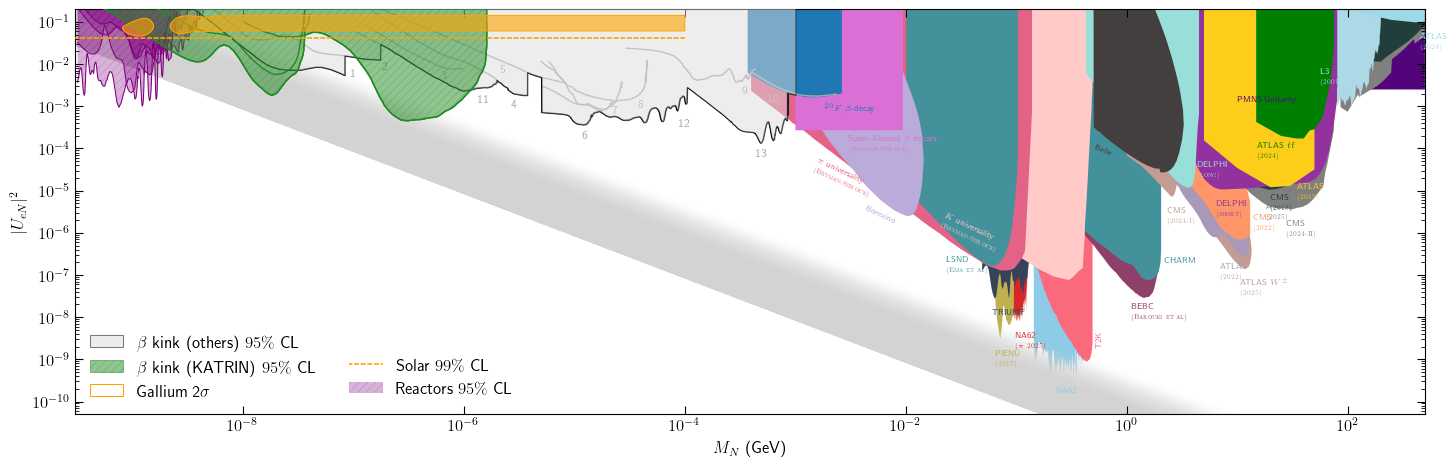

In [6]:
kwargs = {
        'xrange': (3e-10,0.5e3),
        'yrange': (5e-11,2e-1),
        #
        'skip_ids': [
                ],
        #
        'new_color': {
                'borexino': '#BAABDA', #7149C6
                'pienu_lowmass': '#E36387',  #FB2576
                'triumf': '#354259', 
                'pienu_2017': '#BFB051', 
                't2k': '#FA697C', #FF85B3
                'kenu': '#FFCAC8', #FFEBB4 F3CCFF
                'na62': '#8DCBE6',
                'charm': '#43919B',
                'bebc_barouki': '#8F4068', #480032
                'belle': '#423F3E',
                'delphi_long': '#98DED9', #B9FFF8 4CD3C2
                'delphi_short': '#93329E',  
                'atlas_2019_prompt': '#FECD1A', 
                'atlas_2022': '#A799B7', #FE6244 
                'atlas_top_2024': 'green', #FE6244 
                'cms_2024_2': 'grey', 
                'cms_2022': '#FF9668', 
                'cms_2018': '#213E3B',
                'pmns_unitarity': '#52057B', #FBCB0A FFD615 FFD581 213E3B
                'l3': 'lightblue', #39B5E0
                'beta_spectrum': 'orchid',
                'cosmo': 'grey',
                'lsnd_ema': '#43919B',
                },
        #
        'new_dash': {
                'cosmo': (1,(4,2))
                },
        #
        'new_labelpos': {
                'borexino': (4.2e-3,1.7e-6),
                'pienu_lowmass': (1.4e-3,1.2e-5),
                #'kenu': (310e-3,7e-9),
                'kenu': (2e-2,0.6e-6),
                'triumf': (60e-3,1.2e-8),
                'pienu_2017': (64e-3,1.2e-9),
                't2k': (5.2e-1,2e-9),
                'na62': (230e-3, 1.7e-10),
                'bebc_barouki': (1.1,1.5e-8),
                'charm': (2.16,2e-7),
                'belle': (5e-1,7e-5),
                'delphi_long': (4.3,3.5e-5),
                # 'delphi_short': (4e1,8e-6),
                'cms_2022': (1.38e1,2e-6),
                'atlas_2019_prompt': (35,1.1e-5),
                'atlas_2022': (7,1.4e-7),
                'atlas_top_2024': (15,1e-4),
                'pmns_unitarity': (1e1,1.3e-3),
                'l3': (5.6e1,5.6e-3),
                'cms_2018': (2e1,5.8e-6),
                'cosmo': (1.4e-3,2e-10),
                'beta_spectrum': (3e-3,1.5e-4),
                'f_decay': (1.8e-3,0.8e-3),
                'lsnd_ema': (2.3e-2,2e-7),
                },
        #
        'new_rotation':{
                'borexino':-25,
                'pienu_lowmass': -25,
                'kenu': -25,
                't2k': 90,
                'belle': -23,
        },
        #
        # 'force_label_color' : 'black',
        'skip_ids' : ['cosmo'],
        }

fig, ax = plot_tools.std_plot_limits(case_electron, figsize=(15, 5), color_fill=True, linewidth=0.5, **kwargs)

make_mixing_vs_mass_plot(ax, xunits=1e-6)

mN_range = np.geomspace(1e-10, 1e2, 1000)  # GeV
UeN2 = lambda mnu, mN: mnu * 1e-9 / mN  # Convert mnu from eV to GeV
mnu_min = np.sqrt(7e-5)
UeN2_low = UeN2(mnu_min, mN_range)
for mnu in np.geomspace(mnu_min, 0.5, 30):
        UeN2_high = UeN2(mnu, mN_range)
        ax.fill_between(mN_range, UeN2_low, UeN2_high, edgecolor='None', facecolor='lightgrey', alpha=(0.55-mnu)/2, zorder=0+mnu)
        

plot_tools.std_savefig(fig, path='plots/mixing/broader_Ue4SQR.pdf')